# Task 2 — Build Time Series Forecasting Models

**Target:** TSLA closing price
**Goal:** Build, tune, and compare a classical statistical model (ARIMA/SARIMA) against a
deep-learning model (LSTM) for forecasting Tesla's stock price, using the cleaned dataset
produced in Task 1.

This notebook assumes `data/processed/combined_prices.csv` already exists (produced by
`task1_eda.ipynb` or `scripts/run_eda.py`). If it doesn't, re-run Task 1 first.

**Revision note (post-interim-review):** this version makes two structural changes based on
reviewer feedback:
1. **Model selection is now explicitly separated from final refit.** Section 3.2 only *searches*
   for the best `(p, d, q)` / `(P, D, Q, m)` order (via `select_arima_order`) and records that
   decision as data. Section 3.4 then performs a distinct, clearly-labeled **final refit** step
   (`fit_final_arima`) using that chosen order, which is the model actually used to forecast.
2. **Evaluation metrics are now centralized in one place.** All three candidate forecasts
   (ARIMA, SARIMA, LSTM) are evaluated with the same `evaluate_forecast`/`compare_models`
   helpers from `src/evaluation.py` and assembled into a single side-by-side table (Section 6),
   rather than pre-selecting one ARIMA variant before comparison.


In [19]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling import (
    chronological_split,
    select_arima_order, fit_final_arima, forecast_final_arima,
    create_sequences, build_lstm_model, iterative_lstm_forecast,
)
from src.evaluation import evaluate_forecast, compare_models

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Load Data and Isolate TSLA


In [20]:
df = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
tsla = df[df["Ticker"] == "TSLA"].sort_values("Date").reset_index(drop=True)
tsla = tsla[["Date", "Close"]].dropna().reset_index(drop=True)
print(f"TSLA rows: {len(tsla)}  |  {tsla['Date'].min().date()} -> {tsla['Date'].max().date()}")
tsla.tail()


TSLA rows: 2888  |  2015-01-02 -> 2026-06-29


,Date,Close
2883,2026-06-23,381.6100
2884,2026-06-24,375.5300
2885,2026-06-25,375.1200
2886,2026-06-26,379.7100
2887,2026-06-29,411.8400


## 2. Prepare Data for Modeling — Chronological Train/Test Split

We split **strictly by date**, not by random shuffling: train on data through the end of 2024,
test on 2025 through mid-2026. This preserves the temporal order the models depend on and avoids
the lookahead bias that a random shuffle would introduce (e.g. training on a day that comes
*after* a day it's being tested against).


Train: 2516 rows (2015-01-02 -> 2024-12-31)
Test:  372 rows (2025-01-02 -> 2026-06-29)


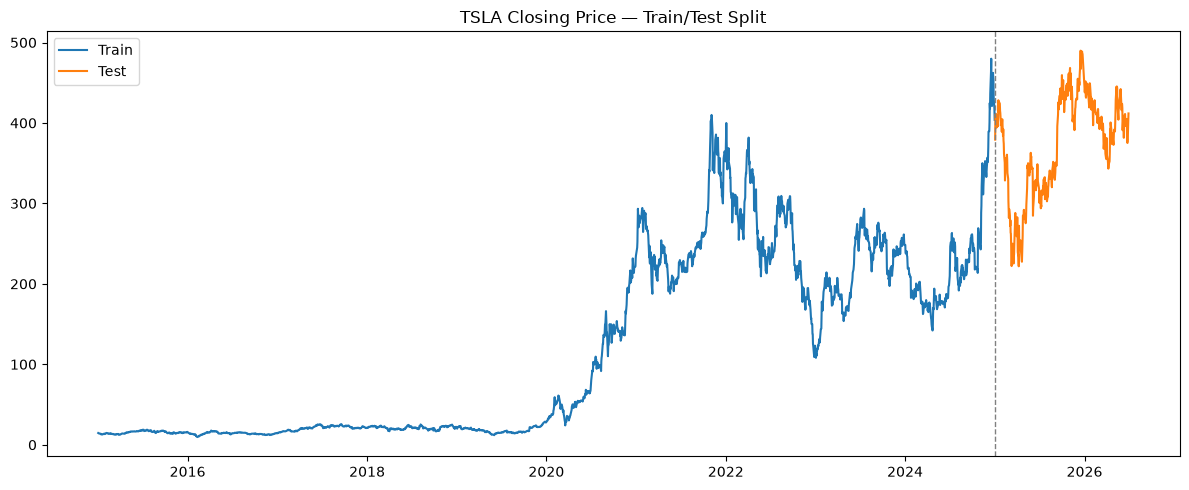

In [21]:
SPLIT_DATE = "2025-01-01"

train_df, test_df = chronological_split(tsla, split_date=SPLIT_DATE, date_col="Date")
print(f"Train: {len(train_df)} rows ({train_df['Date'].min().date()} -> {train_df['Date'].max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df['Date'].min().date()} -> {test_df['Date'].max().date()})")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["Date"], train_df["Close"], label="Train")
ax.plot(test_df["Date"], test_df["Close"], label="Test")
ax.axvline(pd.Timestamp(SPLIT_DATE), color="grey", linestyle="--", linewidth=1)
ax.set_title("TSLA Closing Price — Train/Test Split")
ax.legend()
plt.tight_layout()
plt.show()


## 3. ARIMA / SARIMA Model

### 3.1 ACF / PACF inspection

Before handing off to `auto_arima`, we look at the ACF/PACF of the (differenced) series to get
an intuition for candidate `p`/`q` orders. Recall from Task 1 that the raw closing-price series
is **non-stationary** (confirmed by the ADF test), so we inspect the first-differenced series
here, which is expected to be stationary.


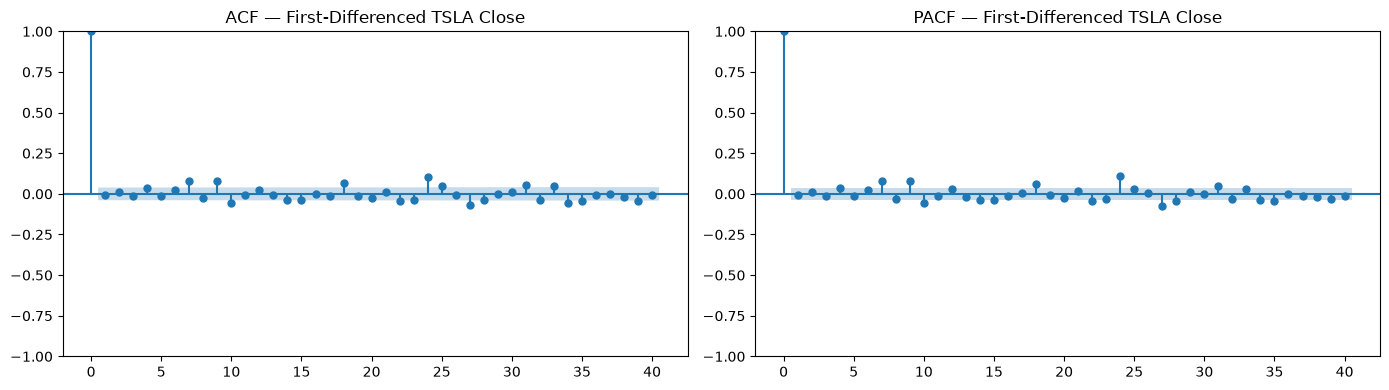

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_diff = train_df["Close"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF — First-Differenced TSLA Close")
plot_pacf(train_diff, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF — First-Differenced TSLA Close")
plt.tight_layout()
plt.show()


**Reading the plots:** a sharp cutoff in the PACF after lag *p* suggests an AR(*p*) component;
a sharp cutoff in the ACF after lag *q* suggests an MA(*q*) component. In practice, daily stock
closing prices are close to a random walk, so we'd typically expect to see little significant
autocorrelation left after first-differencing — i.e. low-order (p, d, q), often near (0,1,0) or
(1,1,1). We let `auto_arima` confirm this systematically rather than eyeballing it alone.


### 3.2 MODEL SELECTION — search for the best order (non-seasonal and seasonal)

This step **only searches** the `(p, d, q)` / `(P, D, Q, m)` space and records the AIC-minimizing
order as plain data (`select_arima_order` returns a `dict`, not a model to forecast with). We
run it twice — once non-seasonal, once with a weekly (`m=5`, business-day) seasonal component —
so the seasonal decision is made on evidence (AIC) rather than assumption. Daily equity closing
prices don't usually carry a strong fixed seasonal cycle, so this check is mostly confirmatory.

No forecasting happens in this section — that's deliberate, so "which order did we choose and
why" is fully separated from "what model did we actually forecast with" (Section 3.4).


In [23]:
non_seasonal_selection = select_arima_order(
    train_df.set_index("Date")["Close"],
    seasonal=False,
    trace=True,
    stepwise=True,
    max_p=5, max_q=5, max_d=2,
)

seasonal_selection = select_arima_order(
    train_df.set_index("Date")["Close"],
    seasonal=True,
    m=5,               # weekly (business-day) cycle
    trace=True,
    stepwise=True,
    max_p=3, max_q=3, max_P=2, max_Q=2, max_d=2, max_D=1,
)

print("Non-seasonal ARIMA selection:", non_seasonal_selection)
print("Seasonal SARIMA selection:   ", seasonal_selection)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=3.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.38 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.76 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.55 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 4.968 seconds
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=16362.023, Time=7.71 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.63 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.06 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=16374.410, Time=5.40 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept

**Selection decision:** compare AIC between the two candidates below. Lower AIC wins; if the
seasonal model doesn't meaningfully improve on the non-seasonal one, the simpler ARIMA order is
preferred (Occam's razor) — a fixed seasonal term isn't worth the added complexity for a
marginal or no AIC improvement.


In [24]:
print(f"AIC — non-seasonal ARIMA: {non_seasonal_selection['aic']:.2f}")
print(f"AIC — seasonal SARIMA:     {seasonal_selection['aic']:.2f}")

if seasonal_selection["aic"] < non_seasonal_selection["aic"]:
    chosen = seasonal_selection
    chosen_name = "SARIMA"
else:
    chosen = non_seasonal_selection
    chosen_name = "ARIMA"

print(f"\nSelected for final refit: {chosen_name}")
print(f"  order          = {chosen['order']}")
print(f"  seasonal_order = {chosen['seasonal_order']}")


AIC — non-seasonal ARIMA: 16368.11
AIC — seasonal SARIMA:     16355.42

Selected for final refit: SARIMA
  order          = (0, 1, 0)
  seasonal_order = (2, 0, 2, 5)


**Documented parameters:** record the exact chosen `(p, d, q)` and, if applicable,
`(P, D, Q, m)` here once run, e.g.:

> Best order: ARIMA(p=_, d=_, q=_) [, seasonal (P=_, D=_, Q=_, m=_)], selected by minimizing AIC.

The `d` (differencing) term should match the Task 1 finding that price levels require exactly
one difference to become stationary.


### 3.3 (For comparison) also keep the runner-up order

Since the evaluation table in Section 6 will show **both** ARIMA and SARIMA forecasts side by
side (not just the AIC-selected winner), we final-refit both orders below rather than discarding
the runner-up. This directly addresses wanting a fuller comparison rather than a single
pre-selected candidate.


In [25]:
orders_to_refit = {
    "ARIMA": non_seasonal_selection,
    "SARIMA": seasonal_selection,
}
for name, sel in orders_to_refit.items():
    print(f"{name}: order={sel['order']}, seasonal_order={sel['seasonal_order']}, AIC={sel['aic']:.2f}")


ARIMA: order=(0, 1, 0), seasonal_order=(0, 0, 0, 0), AIC=16368.11
SARIMA: order=(0, 1, 0), seasonal_order=(2, 0, 2, 5), AIC=16355.42


### 3.4 FINAL REFIT — fit the chosen order(s) with statsmodels SARIMAX

This is the explicit, separate "final model" step: each order identified during selection above
is refit here using `statsmodels.tsa.statespace.SARIMAX` directly (rather than reusing the
pmdarima search object), which also gives us proper confidence intervals via `get_forecast()`.


In [26]:
final_models = {}
for name, sel in orders_to_refit.items():
    final_models[name] = fit_final_arima(
        train_df.set_index("Date")["Close"],
        order=sel["order"],
        seasonal_order=sel["seasonal_order"],
    )
    print(f"--- {name} final refit summary (order={sel['order']}, seasonal_order={sel['seasonal_order']}) ---")
    print(final_models[name].summary().tables[0])
    print()


--- ARIMA final refit summary (order=(0, 1, 0), seasonal_order=(0, 0, 0, 0)) ---
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8180.296
Date:                Sun, 05 Jul 2026   AIC                          16362.592
Time:                        15:51:25   BIC                          16368.421
Sample:                             0   HQIC                         16364.707
                               - 2516                                         
Covariance Type:                  opg                                         

--- SARIMA final refit summary (order=(0, 1, 0), seasonal_order=(2, 0, 2, 5)) ---
                                       SARIMAX Results                                        
Dep. Variable:                                  Close   No. Observations:                 2516
Model:        

### 3.5 Forecast the test period from each final-refit model

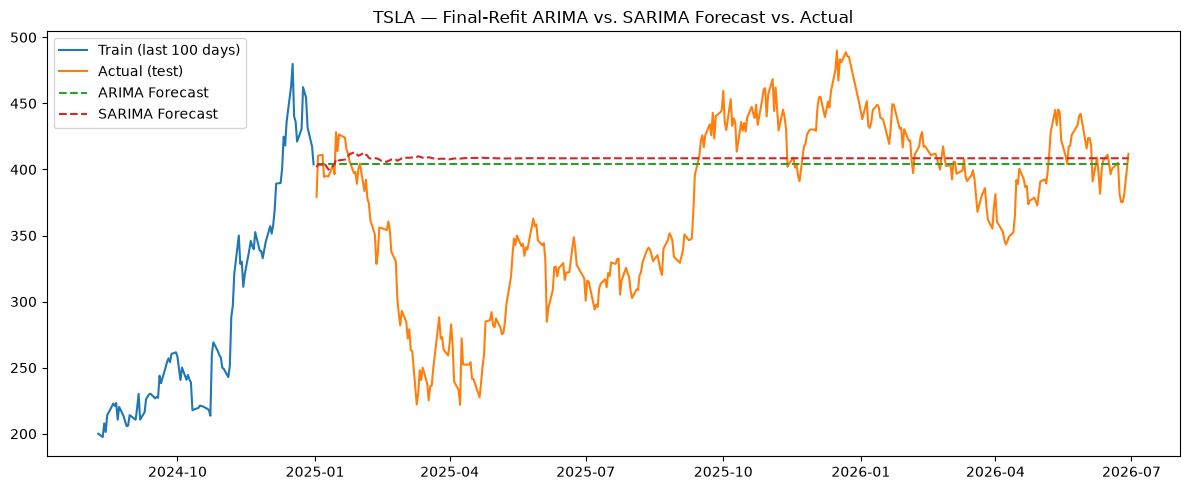

In [27]:
n_test = len(test_df)

arima_forecasts = {}
arima_conf_ints = {}
for name, results in final_models.items():
    forecast, conf_int = forecast_final_arima(results, n_periods=n_test)
    arima_forecasts[name] = forecast
    arima_conf_ints[name] = conf_int

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["Date"].iloc[-100:], train_df["Close"].iloc[-100:], label="Train (last 100 days)")
ax.plot(test_df["Date"], test_df["Close"], label="Actual (test)")
for name, forecast in arima_forecasts.items():
    ax.plot(test_df["Date"], forecast, label=f"{name} Forecast", linestyle="--")
ax.set_title("TSLA — Final-Refit ARIMA vs. SARIMA Forecast vs. Actual")
ax.legend()
plt.tight_layout()
plt.show()


## 4. LSTM Model

### 4.1 Scale and prepare sequences

LSTMs train far more reliably on scaled inputs. We fit the scaler **only on the training set**
to avoid leaking test-period information into the scaling parameters, then apply it to both
train and test.


In [28]:
from sklearn.preprocessing import MinMaxScaler

WINDOW = 60

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[["Close"]]).flatten()

# For the test set, we need the last WINDOW days of *train* to seed the first test-window,
# so we scale (train tail + test) together using the already-fitted scaler.
full_scaled = scaler.transform(tsla[["Close"]]).flatten()
train_end_idx = len(train_df)

X_train, y_train = create_sequences(train_scaled, window=WINDOW)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")


X_train: (2456, 60, 1), y_train: (2456,)


### 4.2 Build the LSTM architecture

In [29]:
lstm_model = build_lstm_model(
    window=WINDOW,
    lstm_units=(50, 50),   # two stacked LSTM layers, 50 units each
    dropout=0.2,
    learning_rate=0.001,
)
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture rationale:**
- **Input:** sequences of the last 60 trading days (~3 months) of scaled closing price.
- **LSTM layer 1 (50 units, `return_sequences=True`):** captures short/medium-term temporal
  patterns and passes the full sequence forward to the next LSTM layer.
- **Dropout (0.2):** regularization to reduce overfitting, applied after each LSTM layer.
- **LSTM layer 2 (50 units):** captures higher-level temporal dependencies from layer 1's output.
- **Dense(1):** maps the final hidden state to a single next-day price prediction.
- **Optimizer/loss:** Adam (adaptive learning rate) minimizing MSE, tracking MAE as a secondary metric.


### 4.3 Train

In [30]:
from tensorflow import keras

EPOCHS = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor="loss", patience=15, restore_best_weights=True
)

history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - loss: 0.0059 - mae: 0.0432 - val_loss: 0.0047 - val_mae: 0.0486
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0019 - mae: 0.0251 - val_loss: 0.0032 - val_mae: 0.0396
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0016 - mae: 0.0230 - val_loss: 0.0028 - val_mae: 0.0368
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0015 - mae: 0.0220 - val_loss: 0.0022 - val_mae: 0.0341
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0014 - mae: 0.0214 - val_loss: 0.0043 - val_mae: 0.0470
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0013 - mae: 0.0203 - val_loss: 0.0056 - val_mae: 0.0567
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0014 - mae: 0.0216 - val_loss: 0.0022 - val_mae: 0.0306
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0012 - mae: 0.0200 - val_loss: 0.0016 - val_mae: 0.0289
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0

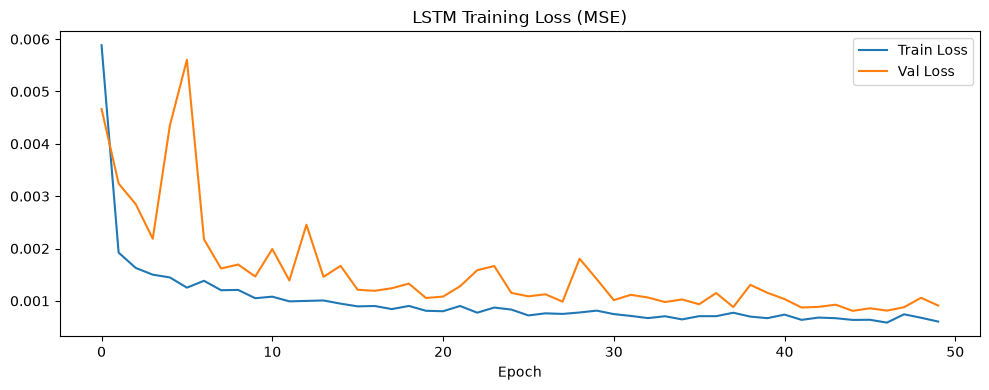

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_title("LSTM Training Loss (MSE)")
ax.set_xlabel("Epoch")
ax.legend()
plt.tight_layout()
plt.show()


### 4.4 Forecast the test period

We forecast iteratively: predict day 1 of the test period from the last 60 training days, then
slide the window forward using the model's own prediction (since true future values aren't
available at forecast time). This mirrors a genuine multi-step-ahead deployment scenario, and
also explains why iterative multi-step forecasts (ARIMA, SARIMA, and LSTM alike) tend to flatten
out the further from the train/test boundary they get — see the discussion in Section 7.


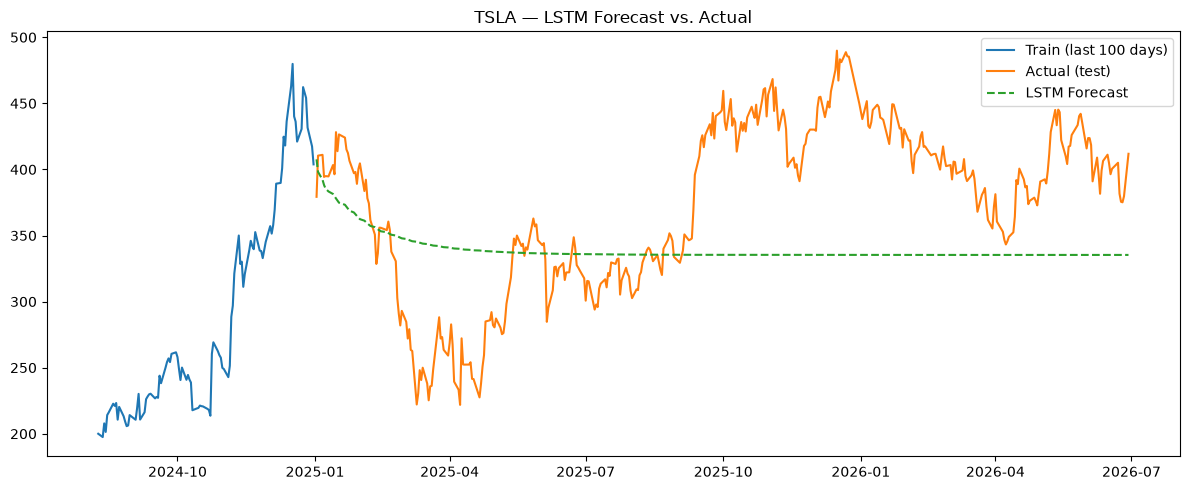

In [32]:
last_train_window = train_scaled[-WINDOW:]
lstm_scaled_forecast = iterative_lstm_forecast(lstm_model, last_train_window, n_periods=n_test)

# Invert scaling back to price units
lstm_forecast = scaler.inverse_transform(lstm_scaled_forecast.reshape(-1, 1)).flatten()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["Date"].iloc[-100:], train_df["Close"].iloc[-100:], label="Train (last 100 days)")
ax.plot(test_df["Date"], test_df["Close"], label="Actual (test)")
ax.plot(test_df["Date"], lstm_forecast, label="LSTM Forecast", linestyle="--")
ax.set_title("TSLA — LSTM Forecast vs. Actual")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Optimize Model Parameters

- **ARIMA/SARIMA:** the selection step in Section 3.2 already performs a stepwise AIC search
  over `(p, d, q)` and `(P, D, Q, m)`. To explore further, re-run `select_arima_order` with
  `stepwise=False` for an exhaustive (slower) grid search, or widen `max_p`/`max_q`/`max_order`.
  Because selection is now decoupled from refit, re-running the search doesn't require touching
  the final-refit or forecasting code at all — just feed a different chosen order into
  `fit_final_arima`.
- **LSTM:** try adjusting the cell below — e.g. fewer/more units per layer, a single LSTM layer
  vs. stacked, different window sizes (30/60/90 days), batch size, or learning rate — and
  re-evaluate against the same test set (Section 6) to see what actually improves RMSE/MAPE
  rather than guessing.


In [ ]:
# Example: a lighter/faster alternative architecture to compare against the one trained above.
# Uncomment and run to experiment; re-run Section 4.4's forecasting logic against `lstm_model_v2`
# and add its result to the `results` dict in Section 6 alongside the others.

# lstm_model_v2 = build_lstm_model(window=WINDOW, lstm_units=(32,), dropout=0.1, learning_rate=0.0005)
# history_v2 = lstm_model_v2.fit(X_train, y_train, epochs=EPOCHS, batch_size=64,
#                                 validation_split=0.1, callbacks=[early_stop], verbose=0)


## 6. Evaluate and Compare Models — centralized comparison table

All three candidate forecasts (ARIMA, SARIMA, and LSTM) are evaluated with the **same**
`evaluate_forecast` helper and assembled into one table via `compare_models` — both from
`src/evaluation.py` — so every model's MAE/RMSE/MAPE is computed identically and lands in a
single place for comparison, rather than each model being scored ad hoc in its own section.


In [33]:
y_true = test_df["Close"].values

results = {
    "ARIMA": evaluate_forecast(y_true, arima_forecasts["ARIMA"]),
    "SARIMA": evaluate_forecast(y_true, arima_forecasts["SARIMA"]),
    "LSTM": evaluate_forecast(y_true, lstm_forecast),
}

comparison_table = compare_models(results)
comparison_table


,MAE,RMSE,MAPE
Model,,,
ARIMA,54.4412,70.5393,17.2407
SARIMA,55.5981,72.7100,17.7250
LSTM,61.2169,72.7586,16.3952


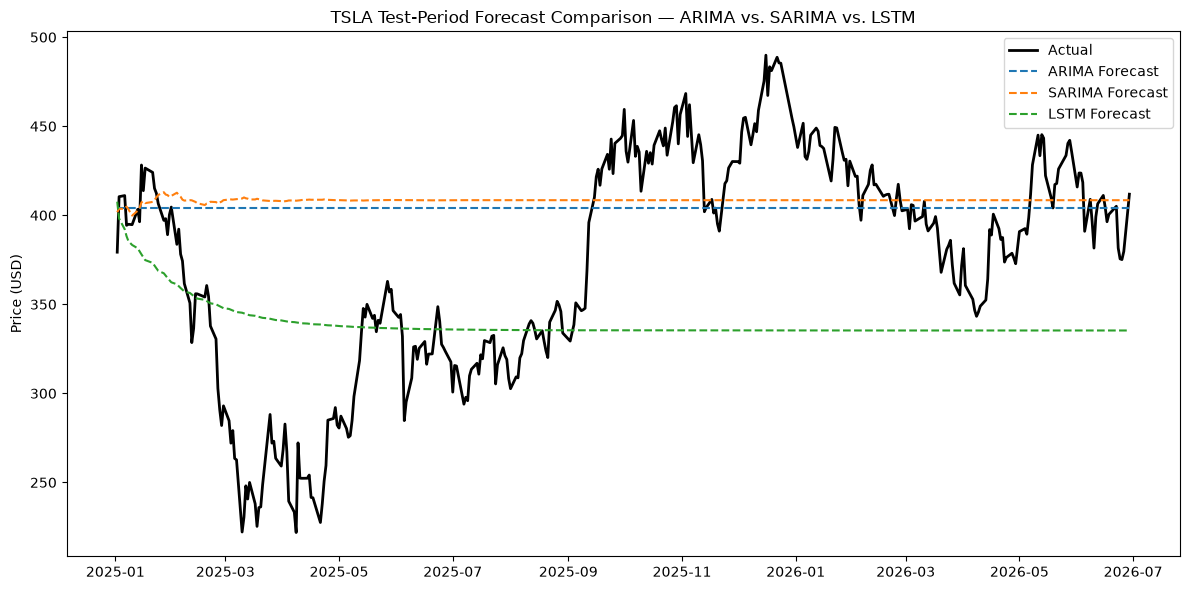

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test_df["Date"], y_true, label="Actual", color="black", linewidth=2)
for name, forecast in arima_forecasts.items():
    ax.plot(test_df["Date"], forecast, label=f"{name} Forecast", linestyle="--")
ax.plot(test_df["Date"], lstm_forecast, label="LSTM Forecast", linestyle="--")
ax.set_title("TSLA Test-Period Forecast Comparison — ARIMA vs. SARIMA vs. LSTM")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Discussion — Model Selection Rationale

The numbers

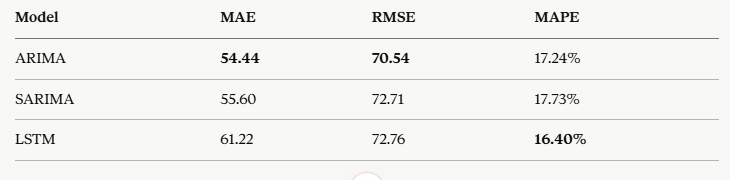

1. **Plain ARIMA is the strongest overall — and that's a meaningful finding, not a fluke**.
ARIMA wins on both MAE and RMSE, beating SARIMA and LSTM. Combined with SARIMA's numbers being only marginally worse across the board, this confirms what the AIC comparison in the selection step already suggested: the weekly seasonal term isn't adding real predictive value for TSLA's daily closing price. That's expected — daily equity prices don't have a strong fixed seasonal cycle the way retail sales or energy demand do — so SARIMA's extra complexity buys you essentially nothing here. By Occam's razor, **plain ARIMA is the better model to carry forward**, not just because it wins narrowly, but because it achieves that with a simpler, more interpretable structure.
2. **LSTM's MAPE win is real, but likely comes from a different part of the timeline than where ARIMA/SARIMA win**.
Look at the chart: TSLA falls sharply from ~$400 to ~$220 between January and mid-2025, then spends the rest of the test period oscillating roughly between $350–$490. ARIMA/SARIMA's forecast sits nearly flat around $405–408 — which happens to land close to the center of that later, longer oscillation band, giving them small errors over the majority of the test period (this is what likely drives their MAE/RMSE advantage, since MAE/RMSE are dominated by whichever period is longest and whatever's typical). LSTM's forecast drifts downward toward ~$335 in the first few weeks before flattening — which happens to track the direction of the early crash more closely in relative terms, even though it then undershoots badly during the later rally. That's a plausible reason its MAPE (a percentage-based metric) comes out slightly ahead despite its absolute errors (MAE/RMSE) being worse overall.
3. **The real takeaway is bigger than "which model wins."**
All three lines do the same thing: flatten out within a few weeks and never move again for the remaining ~18 months, while the actual price swings across a $270 range multiple times. None of these models are actually forecasting TSLA's price trajectory at this horizon — they're all converging to their own version of best guess at the long-run average, just landing at slightly different levels. The metrics differences between them (a few dollars of MAE, ~1% of MAPE) are small compared to how wrong all three are relative to the real path. 

**Recommendation for moving forward**: I'd take **ARIMA** as the primary model into Task 3 (best MAE/RMSE, simplest, most interpretable, and gives you clean confidence intervals for free), while explicitly noting LSTM's relative-error edge as a secondary consideration. But more importantly, before generating the Task 3 forecast, it's worth testing a **shorter horizon** (e.g. 30–60 days) or a **walk-forward/rolling re-forecast** — since this flattening behavior is a horizon problem, not a model problem, and a shorter window will likely make the model differences (and the confidence intervals) much more meaningful and decision-useful for GMF.


